In [1]:
# 01. ENVIRONMENT SETUP & LIBRARIES

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

# Set global visual style
sns.set_theme(style="white")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 11,
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "axes.labelweight": "bold",
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.autolayout": True,
    }
)

In [5]:
# 02. LOAD & INSPECT DATASET

df = pd.read_csv("facebook_restaurant_annoyances.csv")

print(f"Dataset successfully loaded. Shape: {df.shape}")
print("\nSample records:")
print(df.head())

print("\nDemographic sample breakdown (Sex):")
print(df["Sex"].value_counts())

# Define category order matching chart layout
cat_order = [
    "Noisy kids",
    "People/the public",
    "Bad manners",
    "Bad service",
    "Phone calls in public",
    "Bad attitude to servers",
]

Dataset successfully loaded. Shape: (871, 3)

Sample records:
  First Name Sex Annoying thing category
0     Nadine   F       People/the public
1     Joseph   M       People/the public
2       John   M       People/the public
3       Jack   M       People/the public
4   Kimberly   F              Noisy kids

Demographic sample breakdown (Sex):
Sex
M    537
F    334
Name: count, dtype: int64


In [9]:
# 03. CONTINGENCY TABLE & STATISTICAL HYPOTHESIS TESTING

# Cross-tabulation of raw counts
contingency_table = pd.crosstab(
    df["Annoying thing category"], df["Sex"]
).reindex(cat_order)

# Percentage distributions normalized within each gender group (%)
pct_table = (
    pd.crosstab(df["Annoying thing category"], df["Sex"], normalize="columns")
    .reindex(cat_order)
    * 100
)

print("\n--- Raw Response Counts ---")
print(contingency_table)

print("\n--- Percentage Distributions Within Gender Group (%) ---")
print(pct_table.round(1))

# Pearson's Chi-Square Test of Independence
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

# Cramer's V (Effect Size measure)
n_total = len(df)
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))

print("\n--- Inferential Statistics Output ---")
print(f"Chi-Square Statistic (χ²): {chi2:.4f}")
print(f"Degrees of Freedom (dof):  {dof}")
print(f"p-value:                  {p_val:.4e}")
print(f"Cramer's V (Effect Size): {cramers_v:.4f}")

if p_val < 0.05:
    print(
        "\nCONCLUSION: Statistically significant divergence in restaurant annoyances between gender groups (p < 0.05)."
    )


--- Raw Response Counts ---
Sex                        F    M
Annoying thing category          
Noisy kids               127  133
People/the public         50  154
Bad manners               67  118
Bad service               47   71
Phone calls in public     33   48
Bad attitude to servers   10   13

--- Percentage Distributions Within Gender Group (%) ---
Sex                         F     M
Annoying thing category            
Noisy kids               38.0  24.8
People/the public        15.0  28.7
Bad manners              20.1  22.0
Bad service              14.1  13.2
Phone calls in public     9.9   8.9
Bad attitude to servers   3.0   2.4

--- Inferential Statistics Output ---
Chi-Square Statistic (χ²): 29.5614
Degrees of Freedom (dof):  5
p-value:                  1.7989e-05
Cramer's V (Effect Size): 0.1842

CONCLUSION: Statistically significant divergence in restaurant annoyances between gender groups (p < 0.05).


### Inferential Statistics & Hypothesis Testing

#### 1. Hypotheses Formulation
* **Null Hypothesis ($H_0$):** Gender ($X$) and reported restaurant annoyance category ($Y$) are independent. Men and women select annoyance categories from identical underlying probability distributions.
* **Alternative Hypothesis ($H_1$):** Gender ($X$) and reported restaurant annoyance category ($Y$) are dependent. The choice of primary annoyance diverges systematically by gender.

---

#### 2. Statistical Parameters & Test Results

* **Sample Size ($N = 871$):** A sample size near 900 provides strong statistical power to detect small-to-moderate distributional shifts without falling into sample-size over-sensitivity.
* **Degrees of Freedom ($\text{dof} = 5$):** Computed as $(R - 1) \times (C - 1) = (6 - 1) \times (2 - 1) = 5$. With 6 response categories and 2 gender groups, fixing the marginal totals leaves exactly 5 cells free to vary independently.
* **Chi-Square Test Statistic ($\chi^2 = 29.5614$):** Measures the aggregate squared deviation between observed cell counts and expected counts under $H_0$. A value of $29.56$ on 5 degrees of freedom indicates a substantial deviation from uniform theoretical expectation.
* **$p$-Value ($p = 1.80 \times 10^{-5}$):** The probability of observing a distributional discrepancy as large as $\chi^2 = 29.56$ purely due to random sampling noise is less than $0.0018\%$.

**Decision:** Because $p < 0.05$, we reject $H_0$. The divergence in restaurant annoyance profiles between men and women is statistically robust and non-random.

---

#### 3. Effect Size & Practical Significance

* **Cramer's $V = 0.1842$:** Quantifies the strength of association on a standardized scale from $0.0$ (no association) to $1.0$ (perfect association). A value of $0.1842$ confirms a **moderate, meaningful behavioral shift** between demographic groups—large enough to drive practical operational and spatial considerations without representing a total binary polarization.

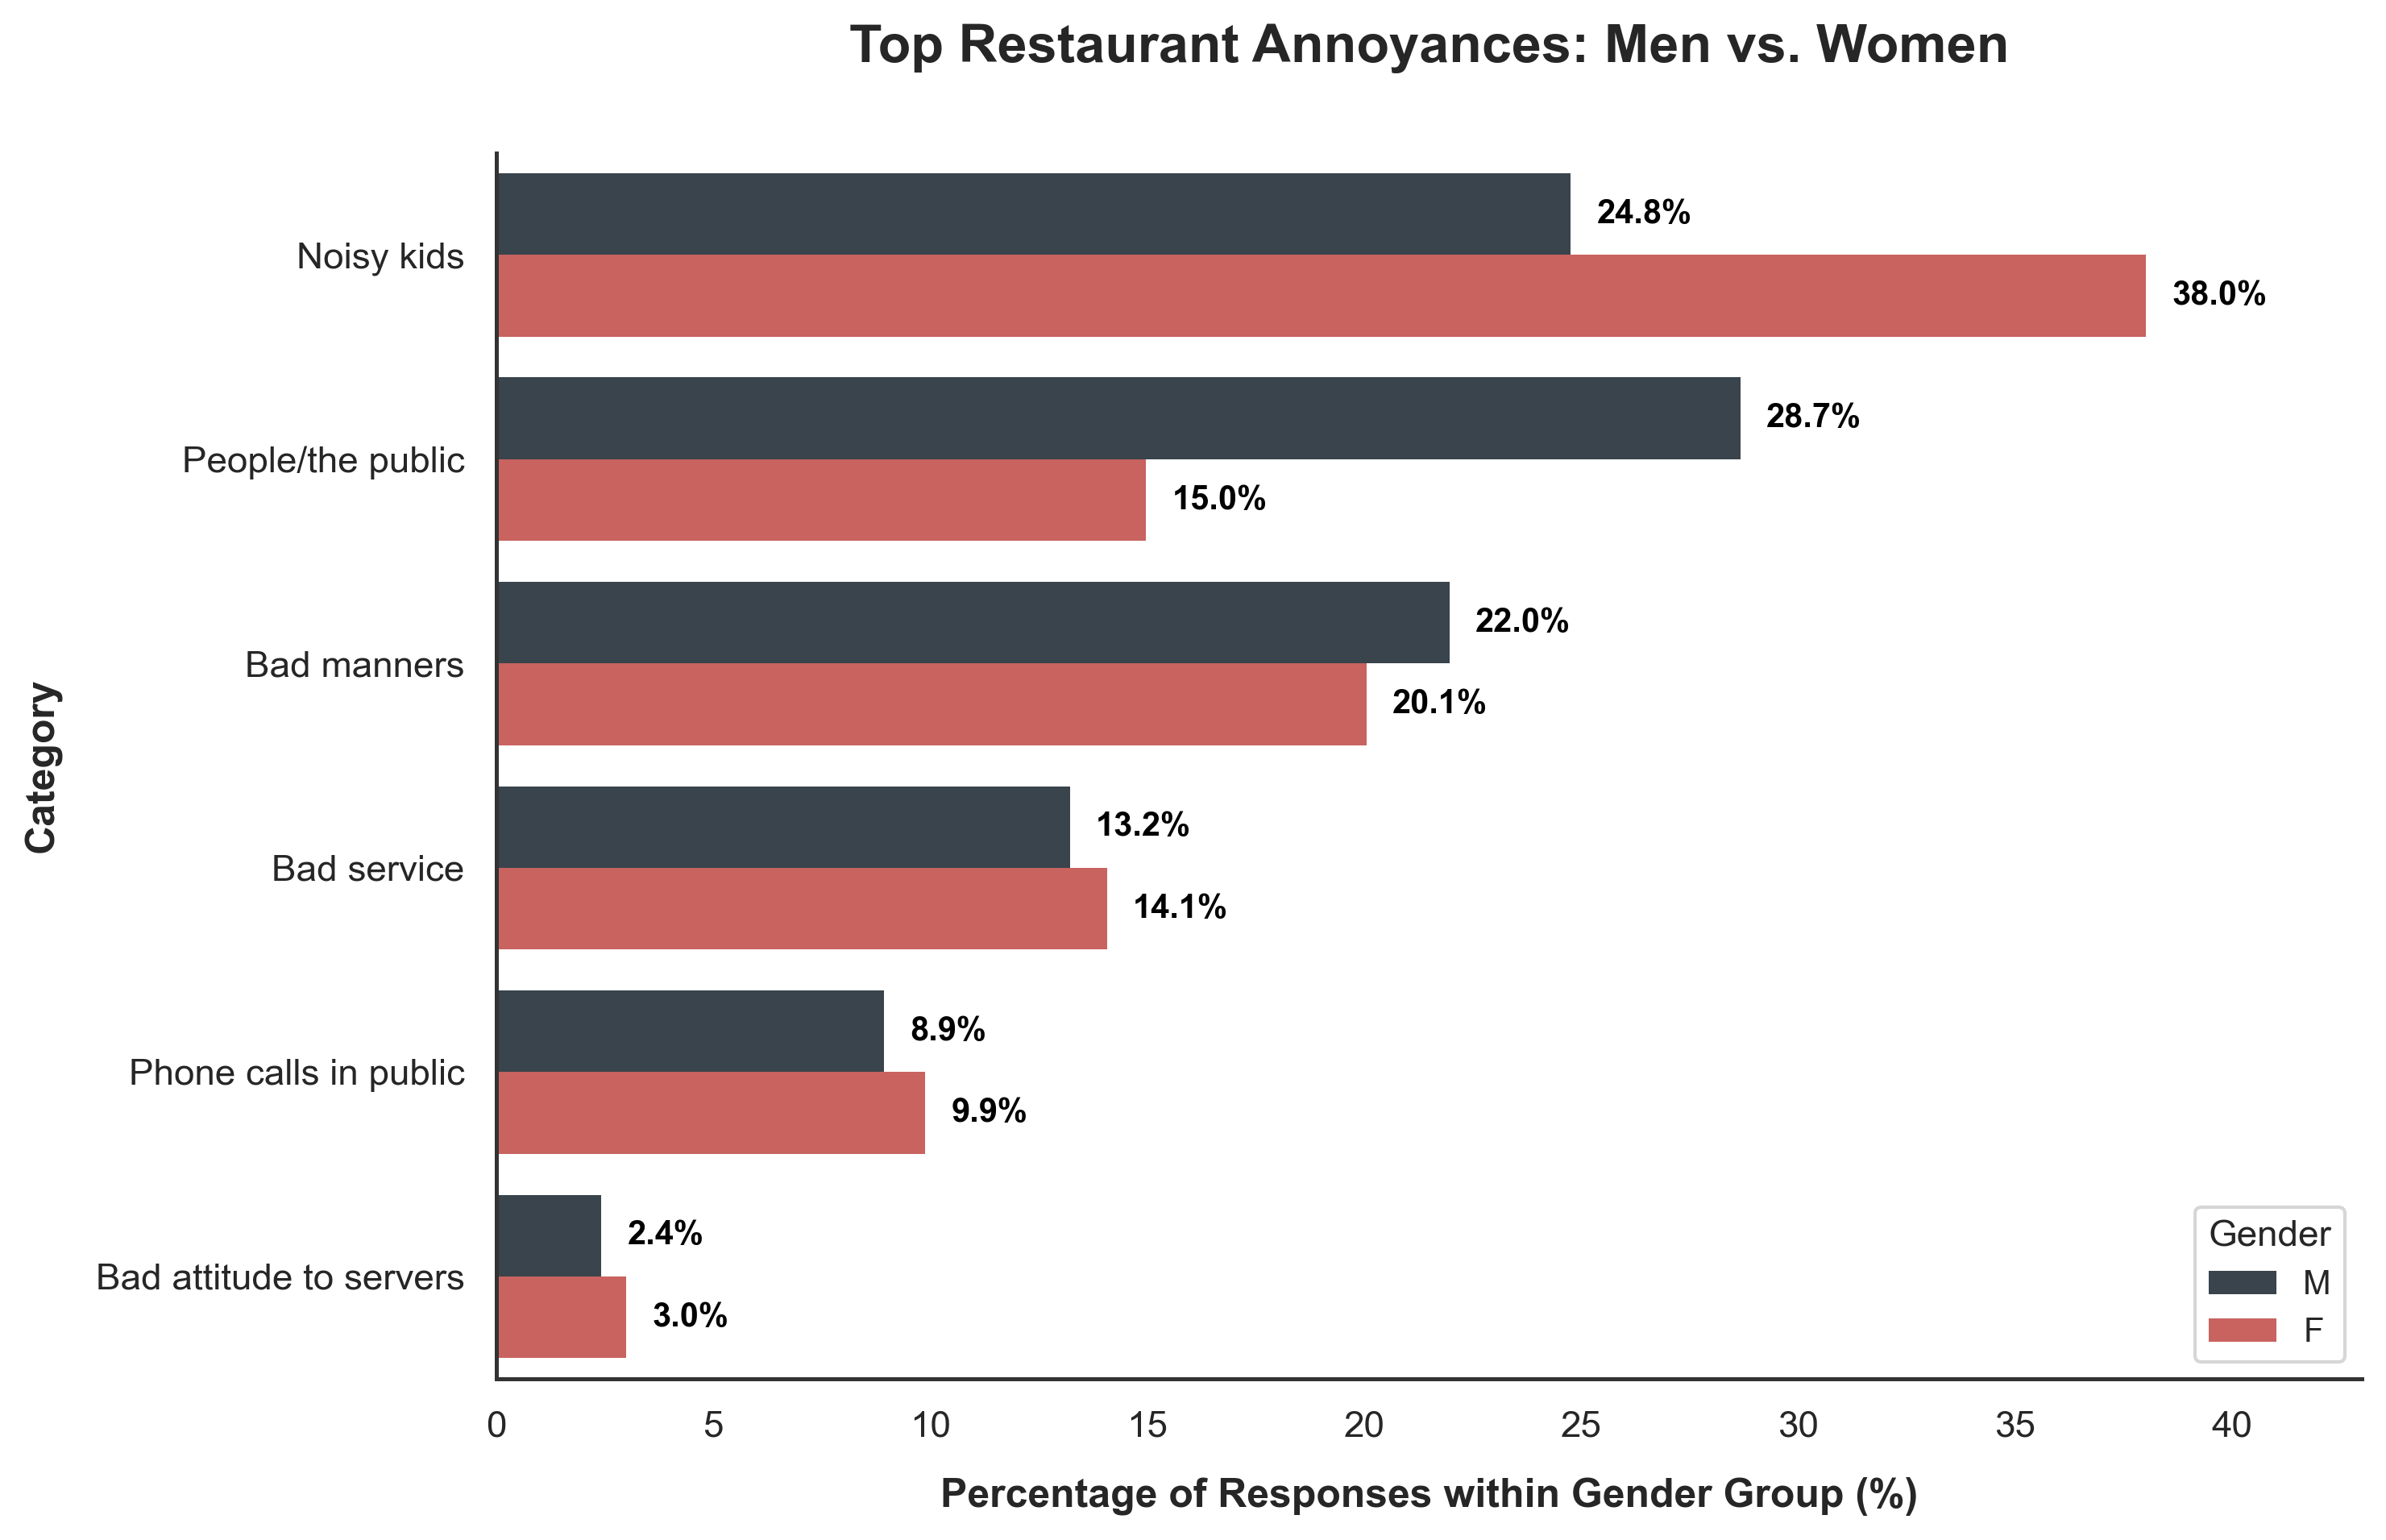

In [12]:
# 04. SEABORN DATA VISUALIZATION

df_pct = (
    pd.crosstab(df["Annoying thing category"], df["Sex"], normalize="columns")
    .unstack()
    .reset_index(name="Percentage")
)
df_pct["Percentage"] = df_pct["Percentage"] * 100
df_pct.columns = ["Gender", "Category", "Percentage"]

# Set categorical order
df_pct["Category"] = pd.Categorical(
    df_pct["Category"], categories=cat_order, ordered=True
)
df_pct = df_pct.sort_values(["Category", "Gender"], ascending=[True, False])

# Initialize figure
fig, ax = plt.subplots(figsize=(10, 6.5), dpi=300)

# Exact color scheme (Dark Slate Blue for Men, Coral Red for Women)
custom_palette = {"M": "#36454F", "F": "#D9534F"}

barplot = sns.barplot(
    data=df_pct,
    y="Category",
    x="Percentage",
    hue="Gender",
    hue_order=["M", "F"],
    palette=custom_palette,
    ax=ax,
    edgecolor="none",
)

# Custom border spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#333333")
ax.spines["bottom"].set_color("#333333")
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Annotate percentages for each bar
for p in barplot.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.1f}%",
            (width + 0.6, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#000000",
        )

# Axis labels & layout
ax.set_title("Top Restaurant Annoyances: Men vs. Women\n", pad=10)
ax.set_xlabel("Percentage of Responses within Gender Group (%)", labelpad=10)
ax.set_ylabel("Category", labelpad=10)
ax.set_xlim(0, 43)

ax.legend(
    title="Gender",
    title_fontsize="11",
    fontsize="10",
    loc="lower right",
    frameon=True,
    facecolor="#ffffff",
    edgecolor="#cccccc",
)

# Render and save high-res figure
plt.tight_layout()
plt.savefig("RESTAURANT.png", dpi=300, bbox_inches="tight")
plt.show()